<table style="border-collapse: collapse; border: none;">
  <tr>
    <td style="vertical-align: top; border: none;">
      <img src="https://i.imgur.com/x6poGzn.png" width="130" height="170" alt="Colaboratory logo" style="margin-right: 10px;">
    </td>
    <td style="border: none;">
      <h1 style="margin-bottom: 0;"><b>Laboratorio 1.4 Potencial y campo eléctrico de un condensador.</b></h1>
      <hr style="margin-top: 5px; margin-bottom: 5px;">
      <div style="font-size: 20px; text-align: left;">
        Física computacional 1.<br>
      </div>
      <div style="font-size: 20px; text-align: left;">
        Nevis Saray Pérez Herrera<br>
      </div>
      <div style="font-size: 13px; text-align: left;">
      <br>Universidad de Antioquia, Instituto de Física<br>
      Abril de 2026.
      </div>
    </td>
  </tr>
</table>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Potencial y campo eléctrico de un condensador

Calcular el potencial generado por un capacitor de dos placas rectangulares de ancho determinado es un desafío (ver figura). En general, podemos realizar alguna aproximación basada en placas infinitas para obtener una idea intuitiva de la solución. En esta aproximación tenemos:

En el campo interior:

$$|E| \approx \frac{\sigma}{2\epsilon_0} $$

En el campo exterior:

$$|E| \approx 0$$


Sin embargo, sabemos que el potencial $\phi$ y el campo eléctrico $\vec{E}$ satisfacen la ecuación de Laplace $\nabla ^2 \phi = 0$ en la región alrededor de las placas (donde $\rho = 0$).


Utilice diferencias finitas para resolver la ecuación de Laplace en las proximidades de este condensador. Utilice la función imshow o contour para graficar el potencial.

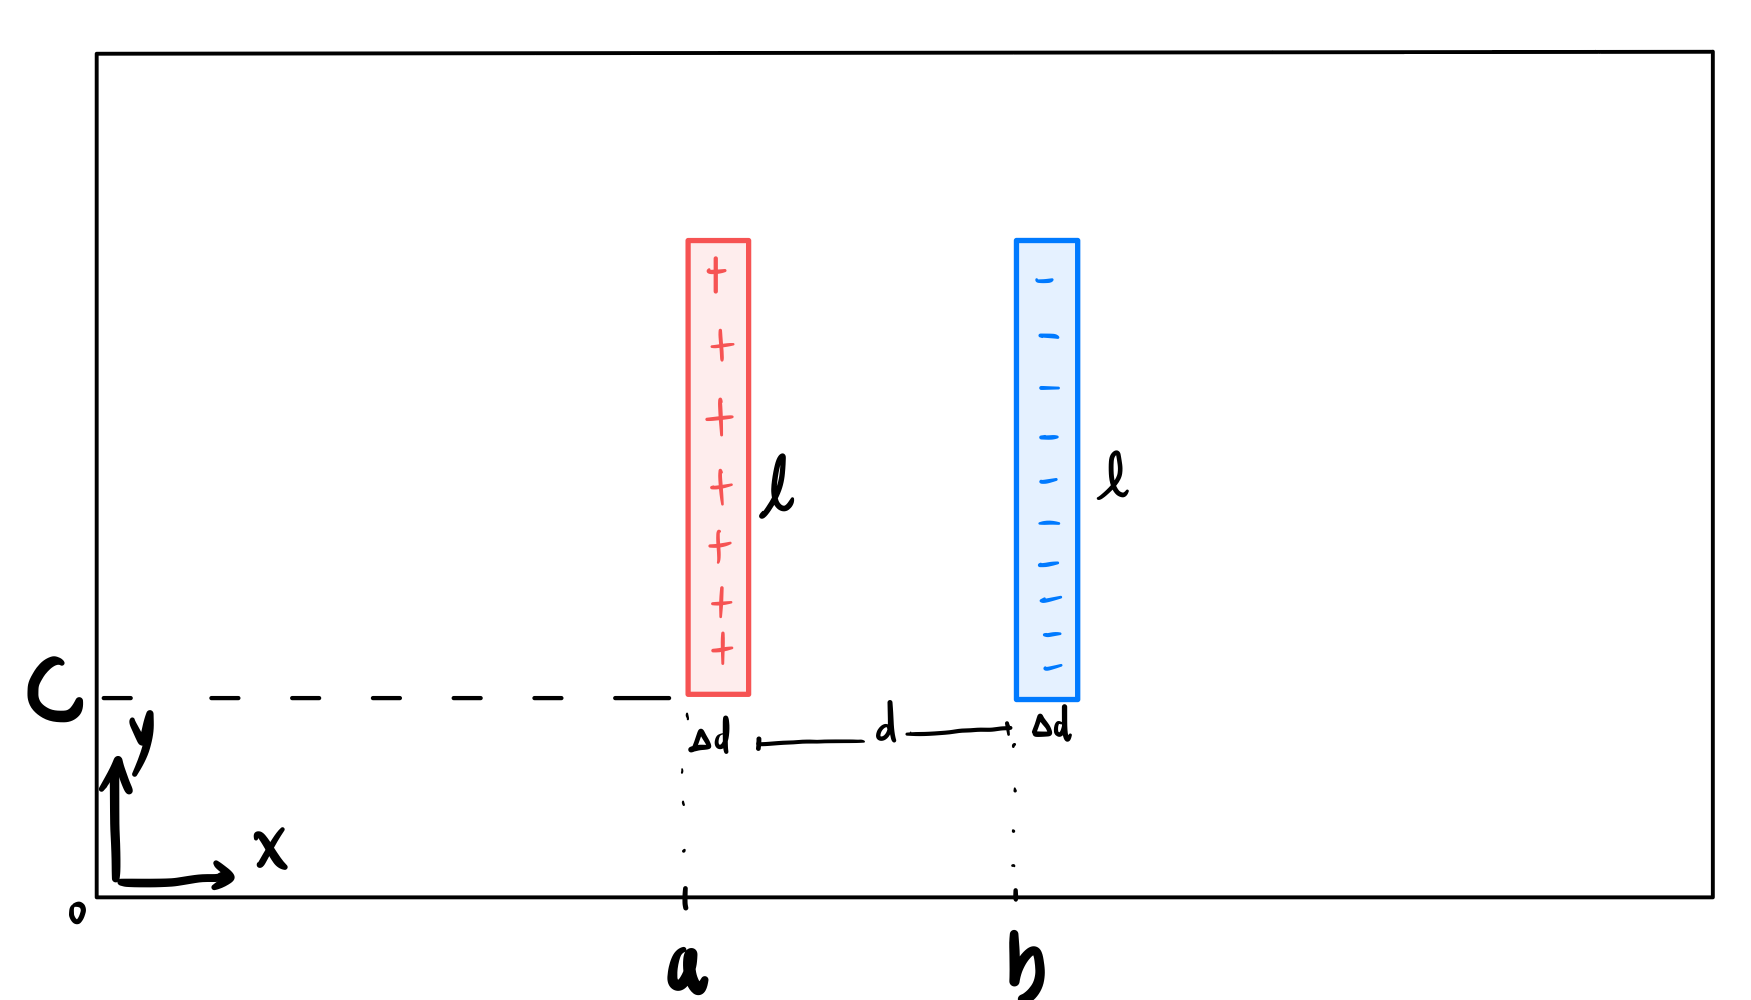

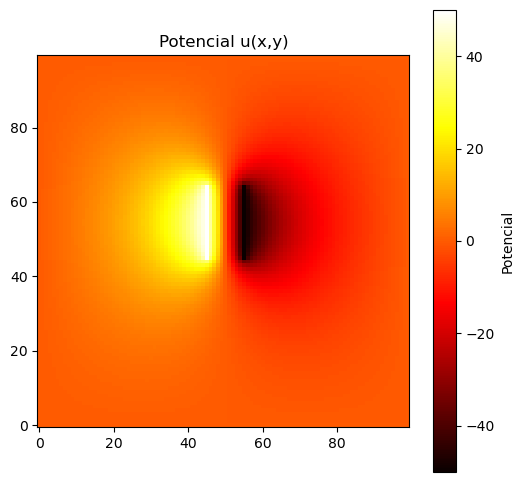

In [3]:
N = 100
V = np.zeros((N, N))
x1, x2 = 45, 55
y1, y2 = 45, 65
V[y1:y2, x1] = 50  # placa positiva
V[y1:y2, x2] = -50 # placa negativa

fixed = np.zeros_like(V, dtype=bool)
fixed[y1:y2, x1] = True
fixed[y1:y2, x2] = True
fixed[0, :] = True
fixed[-1, :] = True
fixed[:, 0] = True
fixed[:, -1] = True

Niter = 2000

for _ in range(Niter):
    V_new = V.copy()
    for i in range(1, N-1):
        for j in range(1, N-1):
            if not fixed[i,j]:
                V_new[i,j] = 0.25 * (V[i+1 ,j] + V[i-1,j] +V[i,j+1] + V[i,j-1])
    V = V_new            

plt.figure(figsize=(6,6))
plt.imshow(V, cmap="hot", origin="lower")
plt.colorbar(label="Potencial")
plt.title("Potencial u(x,y)")
plt.show()

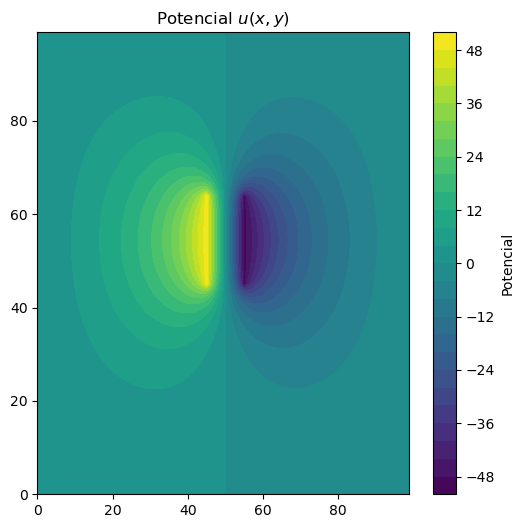

In [4]:
plt.figure(figsize=(6,6))
plt.contourf(V, levels=30, cmap="viridis")
plt.colorbar(label="Potencial")
plt.title("Potencial $u(x,y)$")
plt.show()

Calcula numéricamente (utilizando el método de diferencias finitas) el campo eléctrico.

$$\vec{E} = -\nabla u$$

$$E_x(i,j) \approx -\frac{u_{i+1,j} - u_{i-1,j}}{2h}$$
$$E_y(i,j) \approx -\frac{u_{i,j+1} - u_{i,j-1}}{2h}$$

(con $h = 1$)

In [5]:
Ex = np.zeros_like(V)
Ey = np.zeros_like(V)

for i in range(1, N-1):
    for j in range(1, N-1):
        Ex[i, j] = -(V[i+1, j] - V[i-1, j]) / 2
        Ey[i, j] = -(V[i, j+1] - V[i, j-1]) / 2

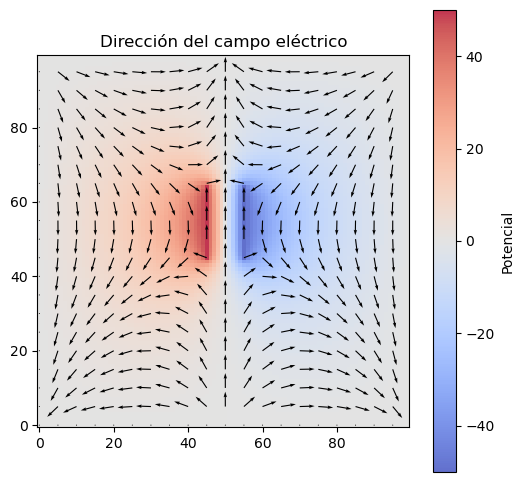

In [ ]:
#Normalizo las flechas
Emag = np.sqrt(Ex**2 + Ey**2)
Exn = Ex / (Emag + 1e-12)
Eyn = Ey / (Emag + 1e-12)

plt.figure(figsize=(6,6))
plt.imshow(V, cmap="coolwarm", origin="lower", alpha=0.8)
plt.colorbar(label="Potencial")

step = 5
Y, X = np.mgrid[0:N:step, 0:N:step]

plt.quiver(X, Y, Exn[::step, ::step], Eyn[::step, ::step],
           color="black", scale=25)

plt.title("Dirección del campo eléctrico")
plt.show()

El potencial es mayor cerca de la placa positiva y menor cerca de la placa negativa. 

El campo eléctrico apunta desde la placa positiva hacia la negativa y presenta curvatura en los bordes esto refleja el efecto de borde del capacitor.